# 01 — Análise Exploratória do ToLD-Br

Dataset: **ToLD-Br** (Toxic Language Dataset – Brazilian Portuguese)  
~21.000 tweets anotados por 3 anotadores com 6 categorias de toxicidade.

Colunas originais: `text`, `homophobia`, `obscene`, `insult`, `racism`, `misogyny`, `xenophobia` (scores 0–3)  
Coluna derivada: `label` (categoria com maior score ≥ 2, ou `not_toxic`)

## 1. Carregamento dos dados

In [1]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid')

DATA_PATH = '../data/raw/toldBr_full.csv'

df = pl.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
df.head(5)

Shape: (21000, 8)


text,homophobia,obscene,insult,racism,misogyny,xenophobia,label
str,f64,f64,f64,f64,f64,f64,str
"""Meu nivel de amizade com isis …",0.0,0.0,2.0,0.0,0.0,0.0,"""insult"""
"""rt @user @user o cara adultera…",0.0,0.0,1.0,0.0,0.0,0.0,"""not_toxic"""
"""@user @user @user o cara só é …",0.0,2.0,1.0,0.0,0.0,0.0,"""obscene"""
"""eu to chorando vei vsf e eu ne…",0.0,1.0,0.0,0.0,0.0,0.0,"""not_toxic"""
"""Eleitor do Bolsonaro é tão ign…",0.0,1.0,2.0,0.0,0.0,0.0,"""insult"""


## 2. Visão geral

In [2]:
print('Colunas:', df.columns)
print('\nTipos:')
print(df.dtypes)
print(f'\nLinhas: {df.height:,}  |  Colunas: {df.width}')

Colunas: ['text', 'homophobia', 'obscene', 'insult', 'racism', 'misogyny', 'xenophobia', 'label']

Tipos:
[String, Float64, Float64, Float64, Float64, Float64, Float64, String]

Linhas: 21,000  |  Colunas: 8


In [3]:
df.describe()

statistic,text,homophobia,obscene,insult,racism,misogyny,xenophobia,label
str,str,f64,f64,f64,f64,f64,f64,str
"""count""","""21000""",21000.0,21000.0,21000.0,21000.0,21000.0,21000.0,"""21000"""
"""null_count""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,"""0"""
"""mean""",null,0.028286,0.460333,0.322429,0.008429,0.029762,0.009905,null
"""std""",null,0.241548,0.770638,0.70354,0.112445,0.216954,0.129091,null
"""min""",""" A Rafaela vivia falando o qua…",0.0,0.0,0.0,0.0,0.0,0.0,"""homophobia"""
"""25%""",null,0.0,0.0,0.0,0.0,0.0,0.0,null
"""50%""",null,0.0,0.0,0.0,0.0,0.0,0.0,null
"""75%""",null,0.0,1.0,0.0,0.0,0.0,0.0,null
"""max""","""🤧🤧🤧🤧🤧 sofro""",3.0,3.0,3.0,3.0,3.0,3.0,"""xenophobia"""


## 3. Distribuição de labels

In [4]:
dist = (
    df['label']
    .value_counts()
    .sort('count', descending=True)
    .with_columns(
        (pl.col('count') / df.height * 100).round(2).alias('pct')
    )
)
print(dist)

shape: (7, 3)
┌────────────┬───────┬───────┐
│ label      ┆ count ┆ pct   │
│ ---        ┆ ---   ┆ ---   │
│ str        ┆ u32   ┆ f64   │
╞════════════╪═══════╪═══════╡
│ not_toxic  ┆ 16937 ┆ 80.65 │
│ obscene    ┆ 2296  ┆ 10.93 │
│ insult     ┆ 1502  ┆ 7.15  │
│ homophobia ┆ 169   ┆ 0.8   │
│ misogyny   ┆ 44    ┆ 0.21  │
│ xenophobia ┆ 31    ┆ 0.15  │
│ racism     ┆ 21    ┆ 0.1   │
└────────────┴───────┴───────┘


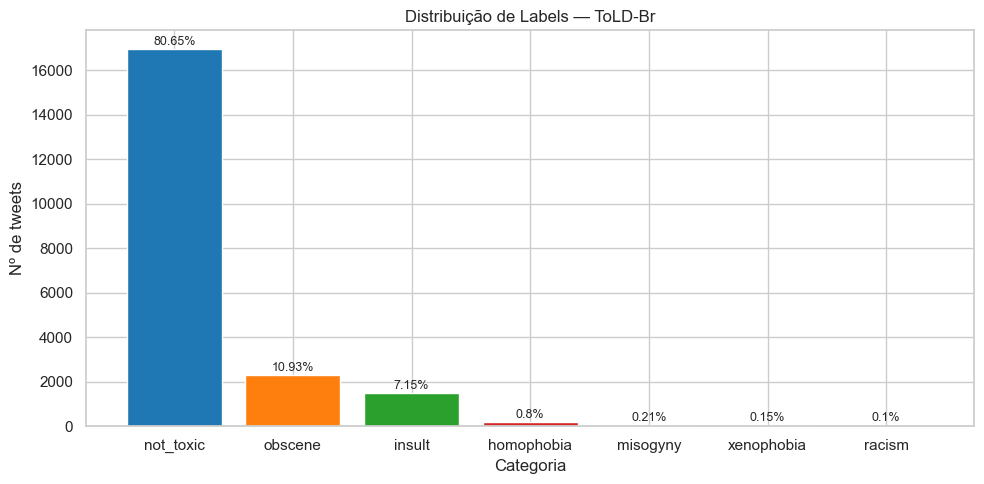

In [5]:
labels = dist['label'].to_list()
counts = dist['count'].to_list()
pcts = dist['pct'].to_list()

fig, ax = plt.subplots()
bars = ax.bar(labels, counts, color=sns.color_palette('tab10', len(labels)))
ax.set_title('Distribuição de Labels — ToLD-Br')
ax.set_xlabel('Categoria')
ax.set_ylabel('Nº de tweets')
for bar, pct in zip(bars, pcts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
            f'{pct}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

## 4. Comprimento dos tweets

In [6]:
df_len = df.with_columns(
    pl.col('text').str.len_chars().alias('n_chars')
)

print('Comprimento médio por label:')
print(
    df_len.group_by('label')
    .agg(pl.col('n_chars').mean().round(1).alias('media_chars'))
    .sort('media_chars', descending=True)
)

Comprimento médio por label:
shape: (7, 2)
┌────────────┬─────────────┐
│ label      ┆ media_chars │
│ ---        ┆ ---         │
│ str        ┆ f64         │
╞════════════╪═════════════╡
│ insult     ┆ 93.1        │
│ xenophobia ┆ 91.8        │
│ not_toxic  ┆ 86.9        │
│ obscene    ┆ 82.3        │
│ homophobia ┆ 78.7        │
│ racism     ┆ 78.1        │
│ misogyny   ┆ 72.9        │
└────────────┴─────────────┘


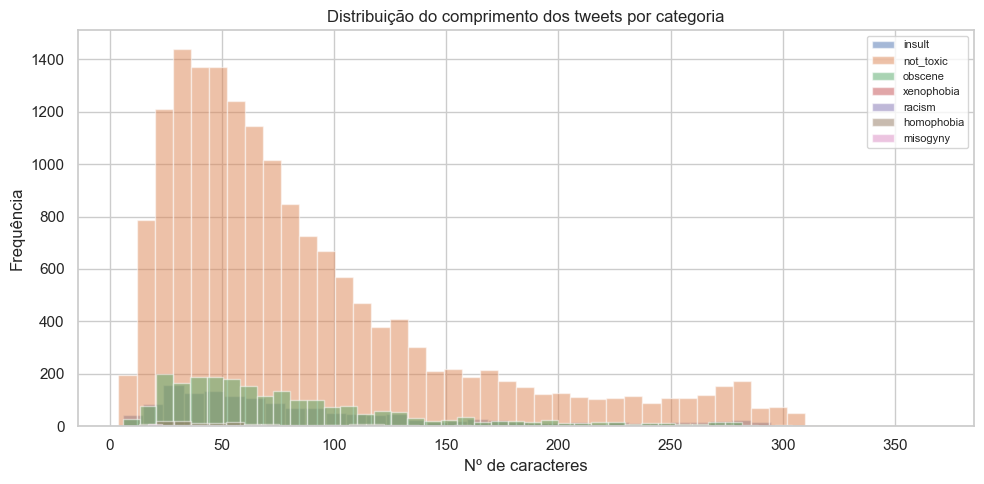

In [7]:
fig, ax = plt.subplots()
data_hist = df_len.select(['label','n_chars']).to_pandas()
for label in data_hist['label'].unique():
    subset = data_hist[data_hist['label'] == label]['n_chars']
    ax.hist(subset, bins=40, alpha=0.5, label=label)
ax.set_title('Distribuição do comprimento dos tweets por categoria')
ax.set_xlabel('Nº de caracteres')
ax.set_ylabel('Frequência')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 5. Análise de nulos e duplicatas

In [8]:
print('Nulos por coluna:')
print(df.null_count())

n_dup = df.filter(df['text'].is_duplicated()).height
print(f'\nTweets duplicados: {n_dup} ({n_dup/df.height*100:.2f}%)')

Nulos por coluna:
shape: (1, 8)
┌──────┬────────────┬─────────┬────────┬────────┬──────────┬────────────┬───────┐
│ text ┆ homophobia ┆ obscene ┆ insult ┆ racism ┆ misogyny ┆ xenophobia ┆ label │
│ ---  ┆ ---        ┆ ---     ┆ ---    ┆ ---    ┆ ---      ┆ ---        ┆ ---   │
│ u32  ┆ u32        ┆ u32     ┆ u32    ┆ u32    ┆ u32      ┆ u32        ┆ u32   │
╞══════╪════════════╪═════════╪════════╪════════╪══════════╪════════════╪═══════╡
│ 0    ┆ 0          ┆ 0       ┆ 0      ┆ 0      ┆ 0        ┆ 0          ┆ 0     │
└──────┴────────────┴─────────┴────────┴────────┴──────────┴────────────┴───────┘

Tweets duplicados: 361 (1.72%)


## 6. Exemplos por categoria

In [9]:
cats = df['label'].unique().to_list()
for cat in sorted(cats):
    print(f'\n=== {cat.upper()} ===')
    sample = df.filter(pl.col('label') == cat).sample(n=3, seed=42)
    for row in sample['text'].to_list():
        print(f'  • {row[:120]}')


=== HOMOPHOBIA ===
  • @user parecendo um traveco
  • arrumar conta é coisa de boiola !
  • @user O comedor de traveco, a direita ta pedindo o impechment do Dias Toffoli faz tempo, você não deve saber porque bloq

=== INSULT ===
  • eu so quero q ela vai toma no cu
  • mlk mais feio tá pra nascer kkkkkkkkkkkk
  • @user @user Vai se lascar sua idiota mentirosa. Você é asquerosa; repúdio é o que o povo brasileiro tem a seu respeito. 

=== MISOGYNY ===
  • rala rala piranha
  • tão duro rezando pra chover vai toma no cu pra lá em filho das puta hoje e só puta acima do peso 😂😂😂
  • rt @user eu que sabotei o copo dessa piranha botei uma bala boa

=== NOT_TOXIC ===
  • eu jurei que ia fazer dieta mês passado p ensaio e cadê, tô mais gorda q antes
  • rt @user cad锚 a boa de hj nesse arax谩
  • tomar no cu viu vei

=== OBSCENE ===
  • rt @user o novinho da nossa foto de perfil mostrando a rola... https://t.co/ecvxkc9wko
  • cara fdp 😠😠😠😠😠😠😠 matou garota de 6 muito bolado com isso😠😠😠😠😠 vai morr

## 7. Balanceamento das classes

O dataset é **altamente desbalanceado**:
- `not_toxic` domina (~80% dos tweets)
- Categorias como `racism`, `xenophobia` e `misogyny` são raras

**Implicação para os experimentos:**
- Usar **F1-macro** como métrica principal (penaliza desbalanceamento)
- A amostragem estratificada (notebook 02) mantém essa proporção real
- Resultados de accuracy podem ser enganosos (baseline ingênuo já acerta ~80%)

In [10]:
toxic_count = df.filter(pl.col('label') != 'not_toxic').height
not_toxic_count = df.filter(pl.col('label') == 'not_toxic').height
print(f'Tóxicos:     {toxic_count:>6,} ({toxic_count/df.height*100:.1f}%)')
print(f'Não-tóxicos: {not_toxic_count:>6,} ({not_toxic_count/df.height*100:.1f}%)')
print(f'Razão not_toxic/toxic: {not_toxic_count/toxic_count:.1f}x')

Tóxicos:      4,063 (19.3%)
Não-tóxicos: 16,937 (80.7%)
Razão not_toxic/toxic: 4.2x
